<h1 style="color:black;font-size:50px;font-family:Georgia;text-align:center;">👨‍💻<strong>Customer <strong style="color:#ff0000;font-size:47px;font-family:Georgia;">Segmentation<strong style="color:black;font-size:50px;font-family:Georgia;"> Analysis</strong></strong></strong>👨‍💻</h1>
<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:17px;border-color:#ff0000;"></p>

## 👥 Group Members

**Name:** Abid Ali  

**ID:** F2023266407

**Name:** M Taha Jamil

**ID:** F2022266379

**Name:** M Ahmad Shahzad 

**ID:** F2022266529

<h1 style="color:black;font-size:40px;font-family:Georgia;text-align:center;">👨‍💻<strong>About DataSet </strong>👨‍💻</h1>
<center><a href="https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv">Train.csv</a></center> </p>
<center><a href="https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=test.csv">Test.csv</a></center> </p>
<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:17px;border-color:#ff0000;"></p>

<h1 style="color:black;font-size:32px;font-family:Georgia;text-align:center;">👨‍💻<strong>Importing <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">The <strong style="color:black;font-size:32px;font-family:Georgia;">Libraries</strong></strong></strong>👨‍💻</h1>

In [1]:
# Loading Necessary Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score, cross_val_predict

<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:17px;border-color:#ff0000;"></p>

<h1 style="color:black;font-size:32px;font-family:Georgia">👨‍💻<strong>Part <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">I: <strong style="color:black;font-size:32px;font-family:Georgia;">Pre-analysis <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">of <strong style="color:black;font-size:32px;font-family:Georgia;">the <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">Data </strong></strong></strong></strong></strong></strong></strong>👨‍💻</h1>

<h1 style="color:black;font-size:32px;font-family:Georgia;text-align:center;">👨‍💻<strong>Loading <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">and <strong style="color:black;font-size:32px;font-family:Georgia;">Reading <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">the <strong style="color:black;font-size:32px;font-family:Georgia;">Dataset </strong></strong></strong></strong></strong>👨‍💻</h1>

In [2]:
# First, load the dataset
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# This steps was created while dealing with Part III,
# fill the NAs using forward fill function
train_data.ffill(inplace = True)
test_data.ffill(inplace = True)

In [3]:
# Show basic information about the datasets
print("Train Dataset Info:")
print(train_data.info())
print("\nTest Dataset Info:")
print(test_data.info())

Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     8068 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        8068 non-null   object 
 5   Profession       8068 non-null   object 
 6   Work_Experience  8068 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      8068 non-null   float64
 9   Var_1            8068 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB
None

Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           -----------

In [4]:
# Printing head data
train_data.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,0.0,High,6.0,Cat_6,A


<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:15px;border-color:#ff0000;"></p>

<h1 style="color:black;font-size:32px;font-family:Georgia;">👨‍💻<strong>Part <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">II: <strong style="color:black;font-size:32px;font-family:Georgia;">Descriptive <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">Analysis </strong></strong></strong></strong></strong>👨‍💻</h1>


In [5]:
# Gender Data preparation
gender = train_data.groupby('Gender').count().reset_index()[['Gender','Age']]
gender.rename(columns = {'Age':'Count'}, inplace = True)
gender

,Gender,Count
0,Female,3651
1,Male,4417


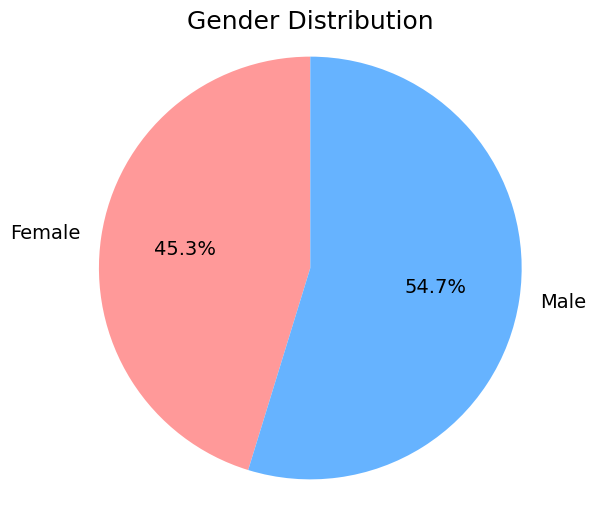

In [6]:
# Gender Distribution Visualization
plt.figure(figsize = (6, 6))
colors = ['#ff9999','#66b3ff']
plt.pie(gender['Count'], labels = gender['Gender'], autopct = '%1.1f%%', startangle = 90, colors = colors, textprops = {'fontsize': 14})

plt.title('Gender Distribution', fontsize = 18)

plt.axis('equal')

plt.show()

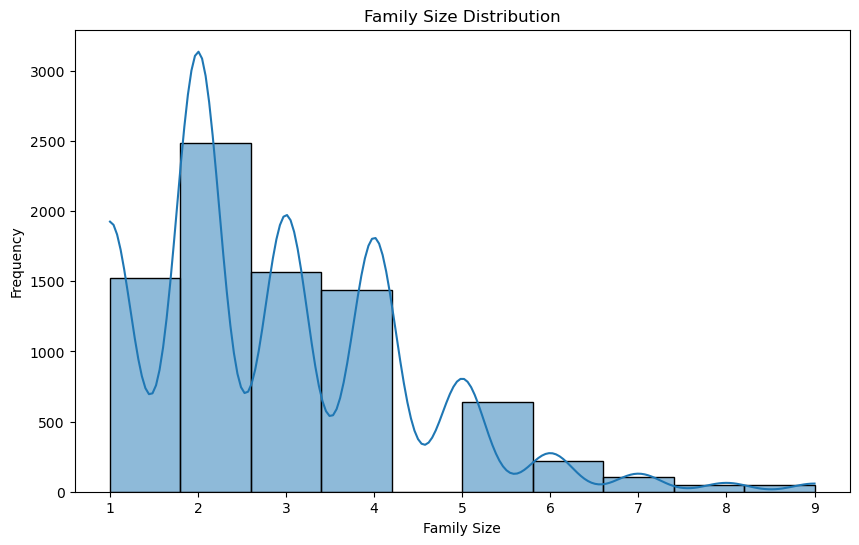

In [7]:
# Family Size Distribution Analysis
plt.figure(figsize = (10, 6))
sns.histplot(train_data['Family_Size'], bins = 10, kde=True)
plt.title('Family Size Distribution')
plt.xlabel('Family Size')
plt.ylabel('Frequency')
plt.show()

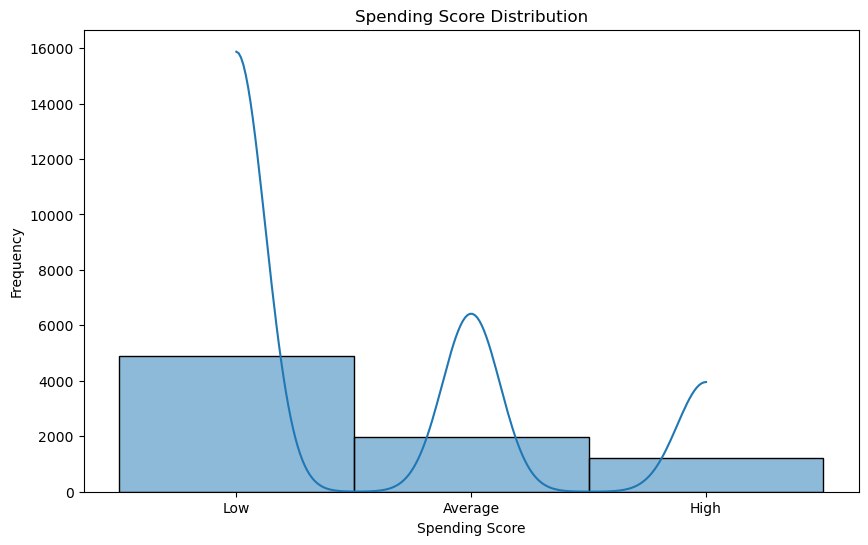

In [8]:
# Spending Score Distribution Visualization
plt.figure(figsize = (10, 6))
sns.histplot(train_data['Spending_Score'], bins  =20, kde = True)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')
plt.show()

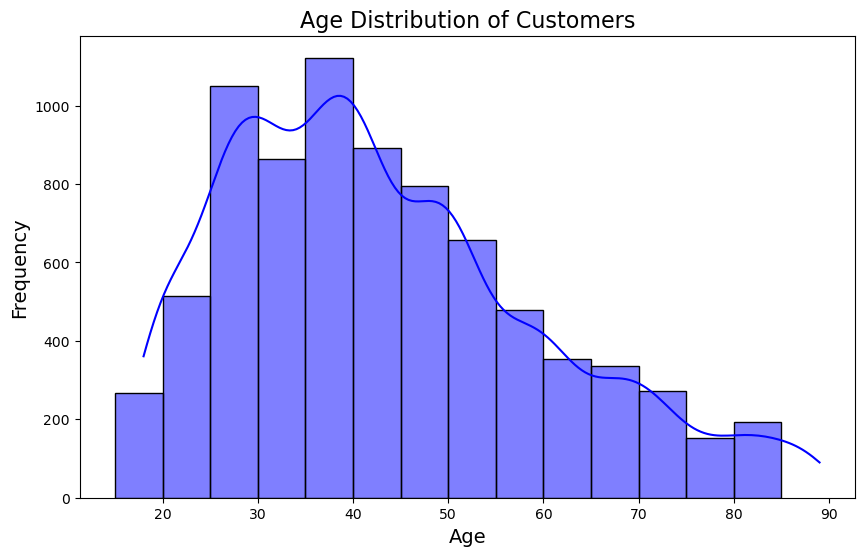

In [9]:
# Age Distribution Visualization

plt.figure(figsize = (10, 6))
sns.histplot(train_data['Age'], bins = list(range(15,90,5)), kde = True, color = 'blue')

plt.title('Age Distribution of Customers', fontsize = 16)
plt.xlabel('Age', fontsize = 14)
plt.ylabel('Frequency', fontsize = 14)

plt.show()

In [10]:
# Spending Power Data preparation, transfer spending_score into numbers
mapping = {'Low': 1, 'Average': 2, 'High': 3}
train_data['Numeric_spending'] = train_data['Spending_Score'].map(mapping)
train_data.head(5)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Numeric_spending
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D,1
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A,2
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B,1
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B,3
4,462669,Female,Yes,40,Yes,Entertainment,0.0,High,6.0,Cat_6,A,3


In [11]:
# Spending Power Data preparation, Final step
Spending_bypro = train_data.groupby('Profession').sum('Numeric_spending').reset_index().sort_values('Numeric_spending', ascending = False)[['Profession', 'Numeric_spending']]
Spending_bypro

,Profession,Numeric_spending
0,Artist,4063
5,Healthcare,1495
4,Executive,1479
3,Entertainment,1381
7,Lawyer,1306
2,Engineer,1046
1,Doctor,953
8,Marketing,386
6,Homemaker,365


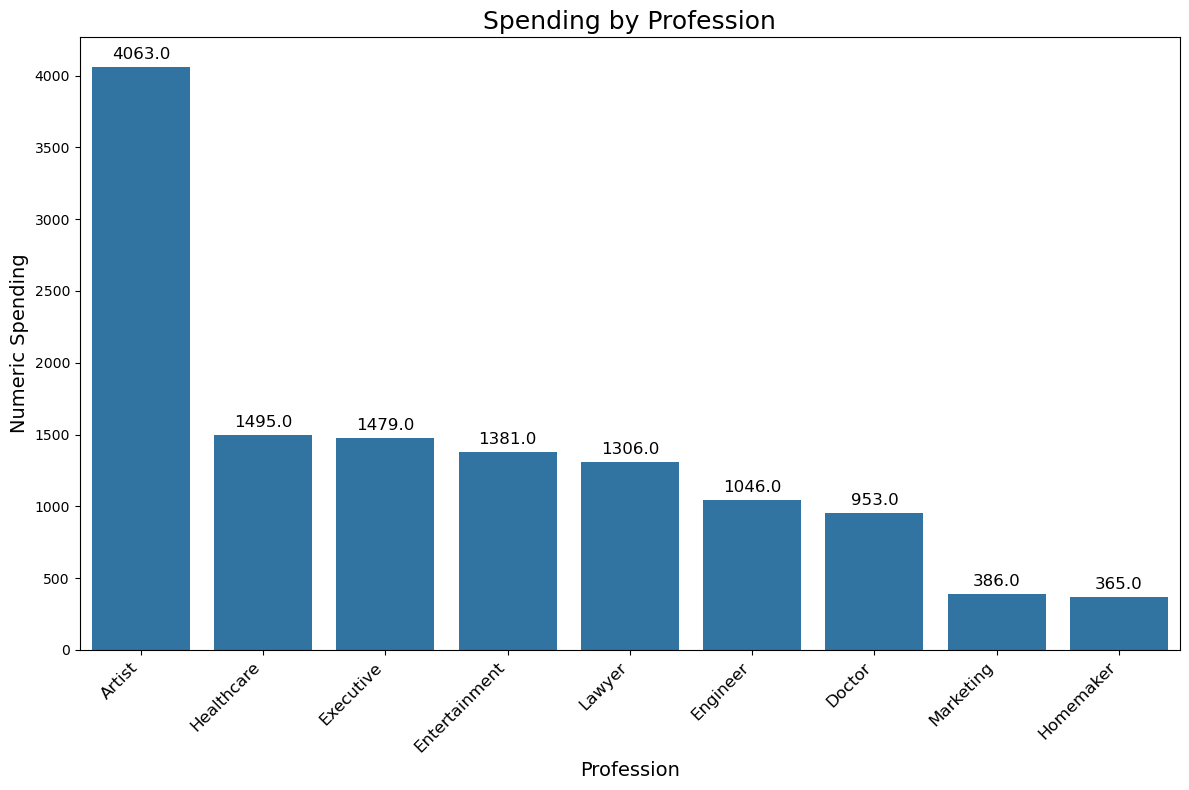

In [12]:
# Spending Power by Profession Visualization
plt.figure(figsize = (12, 8))
bar_plot = sns.barplot(x = 'Profession', y = 'Numeric_spending', data = Spending_bypro)

plt.title('Spending by Profession', fontsize = 18)
plt.xlabel('Profession', fontsize = 14)
plt.ylabel('Numeric Spending', fontsize = 14)

plt.xticks(rotation = 45, ha='right', fontsize = 12)

for p in bar_plot.patches:
    bar_plot.annotate(format(p.get_height(), '.1f'), 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha = 'center', va = 'center', 
                      xytext = (0, 9), 
                      textcoords = 'offset points',
                      fontsize=12)

# Showing Plots
plt.tight_layout()
plt.show()

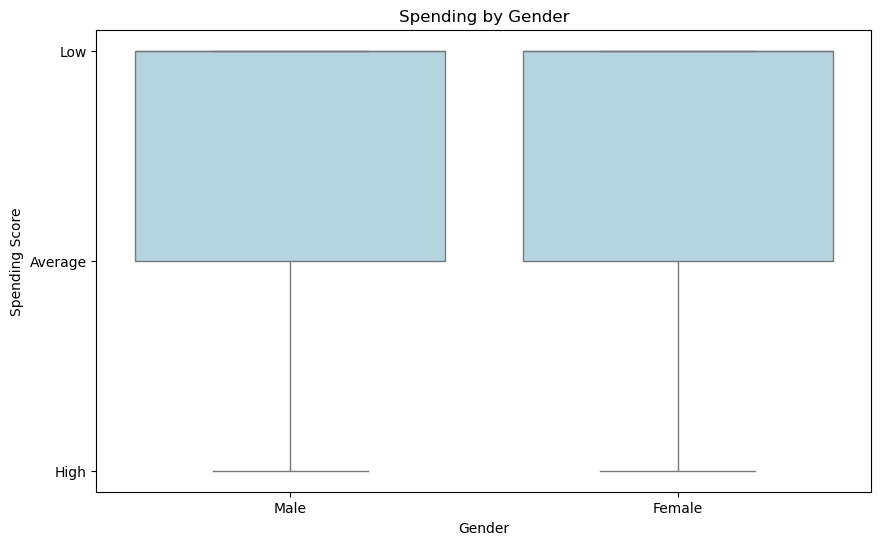

In [13]:
# Create the boxplot for Spending by Gender
plt.figure(figsize = (10, 6))
sns.boxplot(x='Gender', y='Spending_Score', data=train_data, color = "lightblue")
plt.title('Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score')
plt.show()

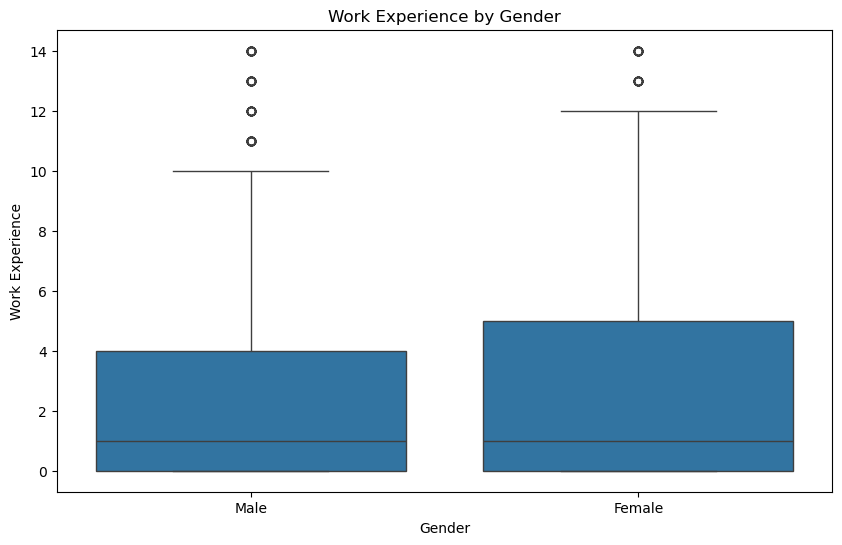

In [14]:
# Work Experience Analysis
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'Gender', y = 'Work_Experience', data = train_data)
plt.title('Work Experience by Gender')
plt.xlabel('Gender')
plt.ylabel('Work Experience')
plt.show()

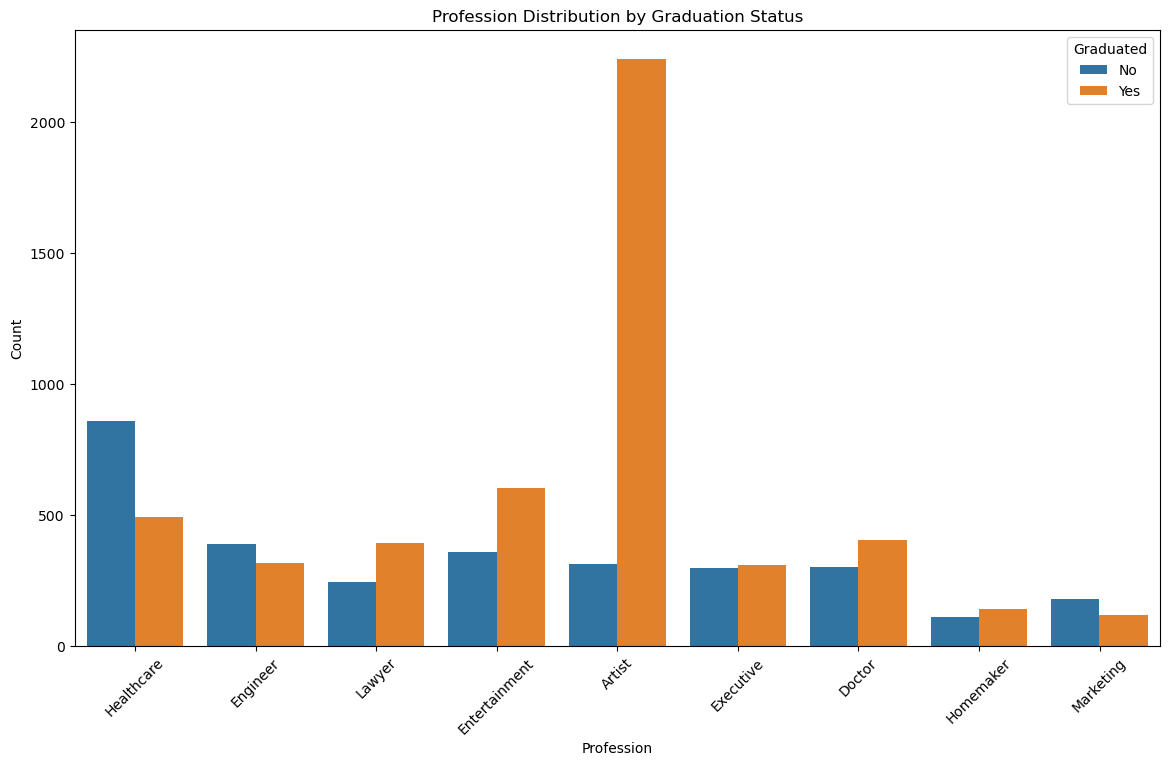

In [15]:
# Graduation Status and Profession
plt.figure(figsize = (14, 8))
sns.countplot(x = 'Profession', hue = 'Graduated', data = train_data)
plt.title('Profession Distribution by Graduation Status')
plt.xlabel('Profession')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

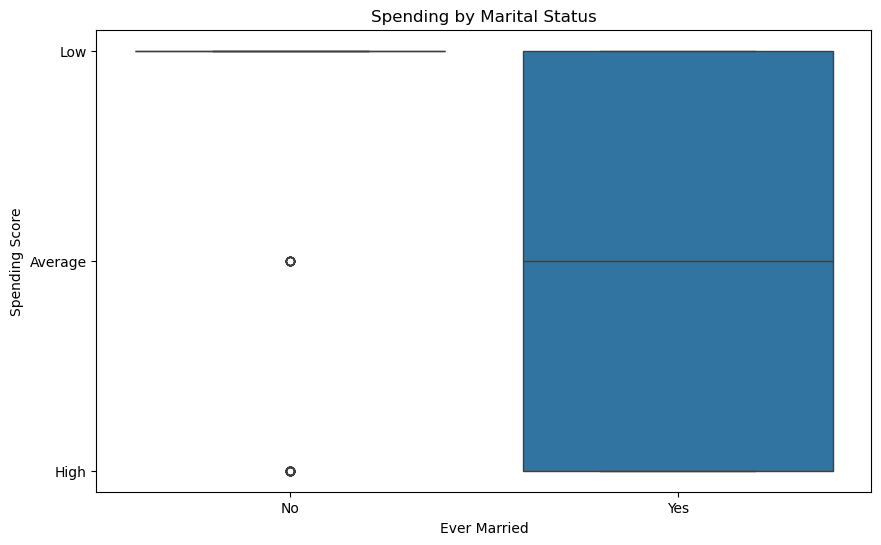

In [16]:
# Marital Status and Spending
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'Ever_Married', y = 'Spending_Score', data = train_data)
plt.title('Spending by Marital Status')
plt.xlabel('Ever Married')
plt.ylabel('Spending Score')
plt.show()

<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:15px;border-color:#ff0000;"></p>

<h1 style="color:black;font-size:32px;font-family:Georgia;">👨‍💻<strong>Correlation <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">Matrix </strong></strong>👨‍💻</h1>

<p>
We aim to create a <strong>correlation matrix</strong> of this <strong>dataset</strong>; however, there are a lot of 
<strong>categorical values</strong> in the dataset. Let us use <strong>LabelEncoder</strong> first before accessing the 
<strong>correlation matrix</strong>.
</p>

In [17]:
# Create a label encoder objects
label_encoder = LabelEncoder()

# List of Categorical values in the data
categorical_columns = [
    'Gender',
    'Ever_Married',
    'Graduated',
    'Profession',
    'Spending_Score',
    'Var_1',
    'Segmentation'
]

# Create a new dataframe to store data
numerical_train = train_data.copy().drop(columns = ['Numeric_spending'])

# Apply label encoding to each categorical columns
for column in categorical_columns:
    numerical_train[column] = label_encoder.fit_transform(numerical_train[column].astype(str))
    
# Check the results
numerical_train.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,1,0,22,0,5,1.0,2,4.0,3,3
1,462643,0,1,38,1,2,1.0,0,3.0,3,0
2,466315,0,1,67,1,2,1.0,2,1.0,5,1
3,461735,1,1,67,1,7,0.0,1,2.0,5,1
4,462669,0,1,40,1,3,0.0,1,6.0,5,0


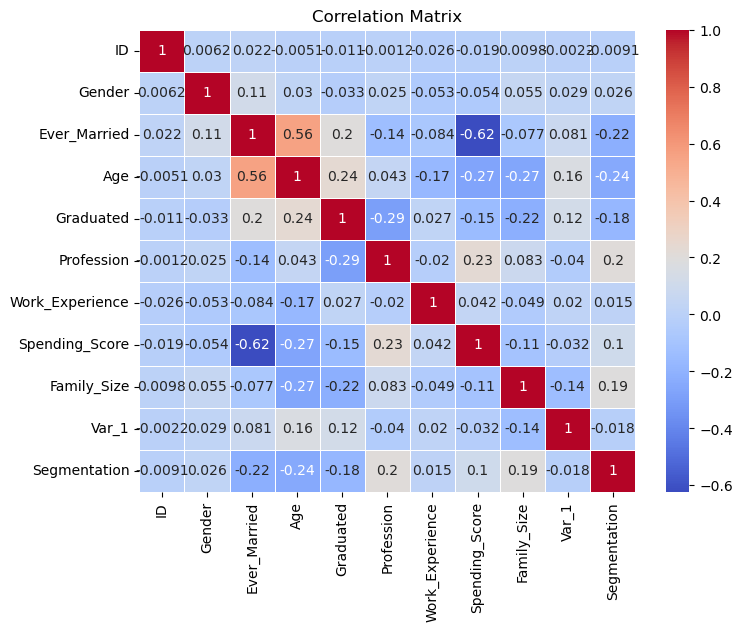

In [18]:
# Correlation Matrix Visualization
plt.figure(figsize = (8, 6))
corr_matrix = numerical_train.corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', linewidths = 0.5)
plt.title('Correlation Matrix')
plt.show()

<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:15px;border-color:#ff0000;"></p>

<h1 style="color:black;font-size:32px;font-family:Georgia;">👨‍💻<strong>Part <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">III: <strong style="color:black;font-size:32px;font-family:Georgia;">Model <strong style="color:#ff0000;font-size:30px;font-family:Georgia;">Selection </strong></strong></strong></strong></strong>👨‍💻</h1>

<div style="font-family:Georgia;color:black;line-height:1.6;">
  <h2 style="font-size:28px;">
    <strong>Analysis</strong>
  </h2>

  <p>
    Throughout this part in <strong>Modeling</strong>, we will mainly focus on the following key areas:
  </p>

  <ol>
    <li>
      <strong>Predictive Modeling for Spending Scores</strong>
      <ul>
        <li>Preferably <strong>Linear Regression</strong>, as we will transform <strong>Spending_Score</strong> into numerical form</li>
        <li><strong>Decision Trees</strong> / <strong>Random Forest Regressor</strong></li>
        <li><strong>Gradient Boosting Regressor</strong></li>
        <li><strong>Support Vector Regressor (SVR)</strong></li>
      </ul>
    </li>
    <li>
      <strong>Customer Segmentation</strong>
      <ul>
        <li>Create new <strong>customer segments</strong> based on clustering techniques</li>
        <li>Examples: <strong>K-Means Clustering</strong> / <strong>Hierarchical Clustering</strong></li>
      </ul>
    </li>
    <li>
      <strong>Customer Segmentation Prediction (Classification)</strong>
      <ul>
        <li>Predict <strong>customer segments</strong> (A, B, C, D) for new potential customers based on <strong>training features</strong></li>
        <li><strong>Logistic Regression</strong> / <strong>Random Forest Classifier</strong> / <strong>Gradient Boosting Classifier</strong></li>
      </ul>
    </li>
    <li>
      <strong>Feature Importance Analysis</strong>
      <ul>
        <li>Identify which <strong>features</strong> are most influential in predicting target values such as <strong>Spending_Score</strong></li>
        <li>Examples: <strong>Random Forest</strong> / <strong>Gradient Boosting</strong></li>
      </ul>
    </li>
  </ol>
</div>

In [19]:
# Define dependent and independent variables (or features and target)
X_train = numerical_train.drop(columns = ['Spending_Score', 'Segmentation'])
Y_train = numerical_train['Spending_Score']

# Create the categorical columns for test now,
# since it does not have 'Segmentation'
categorical_columns_test = [
    'Gender',
    'Ever_Married',
    'Graduated',
    'Profession',
    'Var_1',
    'Spending_Score'
]

# Copy and paste the test_data so that it won't modify the original data
numerical_test = test_data.copy()

# Label Encodering
for column in categorical_columns_test:
    numerical_test[column] = label_encoder.fit_transform(numerical_test[column].astype(str))

# Define dep and indep vars again
X_test = numerical_test.drop(columns = ['Spending_Score'])
Y_test = numerical_test['Spending_Score']

<h2 style="color:black;font-size:28px;font-family:Georgia;">
  👨‍💻 <strong>Linear <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">Regression <strong style="color:black;font-size:28px;font-family:Georgia;">Model </strong></strong></strong>
</h2>

In [20]:
# Start and train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

# Make predictions on the test data
Y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(Y_test, Y_pred_lr)
print(f'Linear Regression MSE: {mse_lr:.4f}')

Linear Regression MSE: 0.4134


<h2 style="color:black;font-size:28px;font-family:Georgia;">
  👨‍💻 <strong>Decision <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">Tree <strong style="color:black;font-size:28px;font-family:Georgia;">Regressor </strong></strong></strong>
</h2>

In [21]:
# Start and train the Decision Tree Regressor Model
dt_model = DecisionTreeRegressor(random_state = 208)
dt_model.fit(X_train, Y_train)

# Make predictions
Y_pred_dt = dt_model.predict(X_test)

# Evaluate model
mse_dt = mean_squared_error(Y_test, Y_pred_dt)
print(f'Decision Tree Regressor MSE: {mse_dt:.4f}')

Decision Tree Regressor MSE: 0.3689


<h2 style="color:black;font-size:28px;font-family:Georgia;">
  👨‍💻 <strong>Random <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">Forest <strong style="color:black;font-size:28px;font-family:Georgia;">Regressor </strong></strong></strong>
</h2>

In [22]:
# Start and train
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 208)
rf_model.fit(X_train, Y_train)

# Make predictions
Y_pred_rf = rf_model.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(Y_test, Y_pred_rf)
print(f'Random Forest Regressor MSE: {mse_rf:.4f}')

Random Forest Regressor MSE: 0.1973


<h2 style="color:black;font-size:28px;font-family:Georgia;">
  👨‍💻 <strong>Gradient <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">Boosting <strong style="color:black;font-size:28px;font-family:Georgia;">Regressor </strong></strong></strong>
</h2>

In [23]:
# Start and train
gbm_model = GradientBoostingRegressor(n_estimators = 100, random_state = 208)
gbm_model.fit(X_train, Y_train)

# Make predictions
Y_pred_gbm = gbm_model.predict(X_test)

# Evaluate Model
mse_gbm = mean_squared_error(Y_test, Y_pred_gbm)
print(f'Gradient Boosting Regressor MSE: {mse_gbm:.4f}')

Gradient Boosting Regressor MSE: 0.3044


<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:17px;border-color:#ff0000;"></p>

<h2 style="color:black;font-size:28px;font-family:Georgia;">
  👨‍💻 <strong>Predictive <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">Modeling <strong style="color:black;font-size:28px;font-family:Georgia;">Summary </strong></strong></strong>
</h2>

In [24]:
# Create Model Performance
mse_performance_summary = {
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Gradient Boosting Regressor'
    ],
    'MSE': [
        mse_lr,
        mse_dt,
        mse_rf,
        mse_gbm
    ]
}

performance_df = pd.DataFrame(mse_performance_summary)
performance_df

,Model,MSE
0,Linear Regression,0.413417
1,Decision Tree Regressor,0.368862
2,Random Forest Regressor,0.197269
3,Gradient Boosting Regressor,0.304380


<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:17px;border-color:#ff0000;"></p>

<h2 style="color:black;font-size:28px;font-family:Georgia;">
  👨‍💻 <strong>Customer <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">Segmentation <strong style="color:black;font-size:28px;font-family:Georgia;">Clustering </strong></strong></strong>
</h2>

<p style="font-family:Georgia;color:black;line-height:1.6;">
  Before doing <strong>clustering modeling</strong>, we need to <strong>standardize</strong> our whole dataset 
  before using clustering methods like <strong>KMeans</strong>.
</p>

<p style="font-family:Georgia;color:black;line-height:1.6;">
  <strong>Objective:</strong> Create new <strong>segments of customers</strong> based on clustering to understand 
  different <strong>customer groups</strong>.
</p>

<p style="font-family:Georgia;color:black;line-height:1.6;">
  <strong>Approach:</strong> Use <strong>clustering techniques</strong> to identify distinct <strong>customer segments</strong>.
</p>

In [25]:
# First, we need to standardize features
scaler = StandardScaler()
scaled_train_data = scaler.fit_transform(numerical_train.drop(columns = ['ID'])) # since we dont need to use 'ID' column

# Second, find out optimal # of k using elbow method
wcss = [] # within-cluster sum of square for elbow method
for i in range(1, 11): # use 10
    kmeans = KMeans(
        n_clusters = i,
        init = 'k-means++',
        max_iter = 300,
        n_init = 10,
        random_state = 208
    )
    kmeans.fit(scaled_train_data)
    wcss.append(kmeans.inertia_)


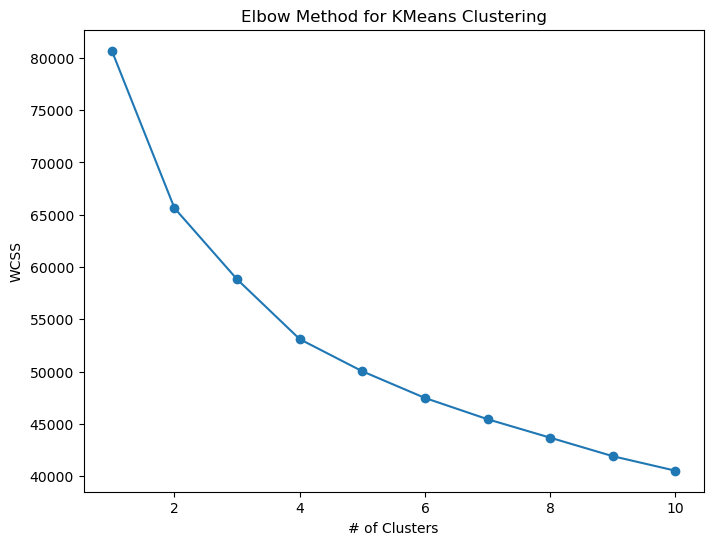

In [26]:
# Thirdly, plot the elbow methods in graph for better visz
plt.figure(figsize = (8, 6))
plt.plot(range(1, 11), wcss, marker = 'o')
plt.title('Elbow Method for KMeans Clustering')
plt.xlabel('# of Clusters')
plt.ylabel('WCSS')
plt.show()

In [27]:
# Apply K-Means with the optimal number of clsuter based on graph above
kmeans = KMeans(
    n_clusters = 4,
    init = 'k-means++',
    max_iter = 300,
    n_init = 10,
    random_state = 208
)
clusters = kmeans.fit_predict(scaled_train_data)

# Add labels to the `numerical_train` dataframe
numerical_train['Cluster'] = clusters

# Analyze the clusters
cluster_analysis = numerical_train.groupby('Cluster').mean()
cluster_analysis

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
Cluster,,,,,,,,,,,
0,463462.096995,0.454463,0.414845,41.377049,0.828324,1.228142,3.112022,1.988160,1.913934,4.196721,0.801002
1,463554.754498,0.586565,0.997201,46.648541,0.757297,1.493003,2.572171,0.240304,3.207117,4.151939,1.410636
2,463415.966318,0.539372,0.086937,27.721438,0.284479,4.321802,2.865726,1.969504,3.739190,3.817478,2.609012
3,463468.670358,0.653322,0.959114,70.063884,0.581772,5.624361,1.333049,1.429302,2.153322,4.602215,1.348382


<ul>
    <li><strong>Cluster 0:</strong> High spenders</li>
    <li><strong>Cluster 1:</strong> Occasional customers</li>
    <li><strong>Cluster 2:</strong> Low-value customers</li>
  </ul>

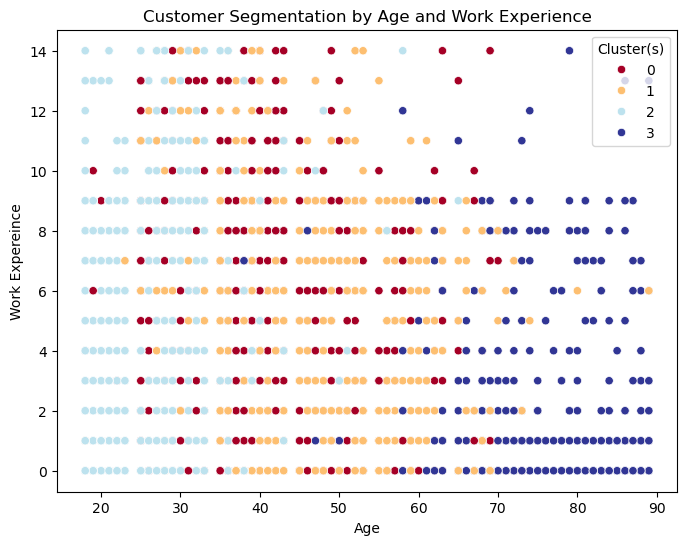

In [28]:
# Visualization of the clustering above
plt.figure(figsize = (8, 6))
sns.scatterplot(
    x = numerical_train['Age'],
    y = numerical_train['Work_Experience'],
    hue = numerical_train['Cluster'],
    palette = 'RdYlBu'
)
plt.title('Customer Segmentation by Age and Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Expereince')
plt.legend(title = 'Cluster(s)')
plt.show()

<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:17px;border-color:#ff0000;"></p>

<h2 style="color:black;font-size:28px;font-family:Georgia;">
  👨‍💻 <strong>Customer <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">Segmentation <strong style="color:black;font-size:28px;font-family:Georgia;">Prediction (CSP) <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">(Using Classification)</strong></strong></strong></strong>
</h2>

In [29]:
# Then, seperate features from data
X_train_class = numerical_train.drop(columns = ['Segmentation', 'ID', 'Cluster']) # remove cluster as we do not need it here
Y_train_class = numerical_train['Segmentation']
X_test_class = numerical_test.drop(columns = ['ID'])
# Y_test_class does not exist as there is no Segmentation in test_data

In [30]:
# Logistic Regression
logreg_model = LogisticRegression(max_iter = 1000, random_state = 208)
logreg_model.fit(X_train_class, Y_train_class)

# Predict segments for the test data
test_data['LogReg_Segmentation'] = logreg_model.predict(X_test_class)

In [31]:
# Random Forest Classifer
rfc_model = RandomForestClassifier(n_estimators = 100, random_state = 208)
rfc_model.fit(X_train_class, Y_train_class)

# Predict segments
test_data['RFC_Segmentation'] = rfc_model.predict(X_test_class)

In [32]:
# Gradient Boosting Classifer
gbc_model = GradientBoostingClassifier(n_estimators = 100, random_state = 208)
gbc_model.fit(X_train_class, Y_train_class)

# Predict segments
test_data['GBC_Segmentation'] = gbc_model.predict(X_test_class)

In [33]:
# Display the first few rows of `test_data` with the predicted segments
print(test_data[['ID', 'LogReg_Segmentation', 'RFC_Segmentation', 'GBC_Segmentation']].head())

       ID  LogReg_Segmentation  RFC_Segmentation  GBC_Segmentation
0  458989                    0                 1                 0
1  458994                    2                 2                 1
2  458996                    0                 0                 3
3  459000                    0                 2                 1
4  459001                    3                 3                 3


In [34]:
# Decode the predicted segments back to the original labels (A, B, C, D)
# test_data['LogReg_Segmentation'] = label_encoder.inverse_transform(test_data['LogReg_Segmentation'])
# test_data['RFC_Segmentation'] = label_encoder.inverse_transform(test_data['RFC_Segmentation'])
# test_data['GBC_Segmentation'] = label_encoder.inverse_transform(test_data['GBC_Segmentation'])
# Tried inverse transform, did not work

# Define the labels to be mapping
label_mapping = {
    0 : 'A',
    1 : 'B',
    2 : 'C',
    3 : 'D'
}

# Mannually transform the labels to original labels
test_data['LogReg_Segmentation'] = test_data['LogReg_Segmentation'].map(label_mapping)
test_data['RFC_Segmentation'] = test_data['RFC_Segmentation'].map(label_mapping)
test_data['GBC_Segmentation'] = test_data['GBC_Segmentation'].map(label_mapping)

# Display the first 5 rows again to verify it works
print(test_data[['ID', 'LogReg_Segmentation', 'RFC_Segmentation', 'GBC_Segmentation']].head(10))

       ID LogReg_Segmentation RFC_Segmentation GBC_Segmentation
0  458989                   A                B                A
1  458994                   C                C                B
2  458996                   A                A                D
3  459000                   A                C                B
4  459001                   D                D                D
5  459003                   C                C                B
6  459005                   B                A                C
7  459008                   C                C                C
8  459013                   C                C                C
9  459014                   D                D                D


In [35]:
# Now, with the Segmentations predicted by LogReg, RFC, and GBC,
# let us do a comparison consistency of predictions
consistency_comparison = test_data[['LogReg_Segmentation', 'RFC_Segmentation', 'GBC_Segmentation']].apply(pd.Series.value_counts)
print(consistency_comparison)

   LogReg_Segmentation  RFC_Segmentation  GBC_Segmentation
A                  711               636               718
B                  244               567               472
C                  784               633               609
D                  888               791               828


Although the results are in, we do not know which method we can trust than other methods to potentially decrease costs in developing these models when new customers come in

In [36]:
# Cross Validation Accuracy for Logistic Regression
logreg_cv_scores = cross_val_score(logreg_model, X_train_class, Y_train_class, cv = 5, scoring = 'accuracy')
Y_train_logreg_pred = cross_val_predict(logreg_model, X_train_class, Y_train_class, cv = 5)

print("Logistic Regression Classification Report:")
print(classification_report(Y_train_class, Y_train_logreg_pred))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(Y_train_class, Y_train_logreg_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.44      0.43      1972
           1       0.35      0.14      0.20      1858
           2       0.48      0.61      0.54      1970
           3       0.61      0.74      0.67      2268

    accuracy                           0.49      8068
   macro avg       0.46      0.48      0.46      8068
weighted avg       0.47      0.49      0.47      8068

Logistic Regression Confusion Matrix:
[[ 875  189  413  495]
 [ 587  257  751  263]
 [ 283  203 1192  292]
 [ 393   77  129 1669]]


In [37]:
# Cross Validation for Random Forest Classifier
rfc_cv_scores = cross_val_score(rfc_model, X_train_class, Y_train_class, cv = 5, scoring = 'accuracy')
Y_train_rfc_pred = cross_val_predict(rfc_model, X_train_class, Y_train_class, cv = 5)

print("Random Forest Classifier Classification Report:")
print(classification_report(Y_train_class, Y_train_rfc_pred))
print("Random Forest Classifier Confusion Matrix:")
print(confusion_matrix(Y_train_class, Y_train_rfc_pred))

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.41      0.41      1972
           1       0.36      0.33      0.34      1858
           2       0.51      0.51      0.51      1970
           3       0.62      0.67      0.64      2268

    accuracy                           0.49      8068
   macro avg       0.47      0.48      0.48      8068
weighted avg       0.48      0.49      0.48      8068

Random Forest Classifier Confusion Matrix:
[[ 804  460  259  449]
 [ 452  604  560  242]
 [ 261  449  998  262]
 [ 429  186  129 1524]]


In [38]:
# Cross Validation for Gradient Boosting Classifier
gbc_cv_scores = cross_val_score(gbc_model, X_train_class, Y_train_class, cv = 5, scoring = 'accuracy')
Y_train_gbc_pred = cross_val_predict(gbc_model, X_train_class, Y_train_class, cv = 5)

print("Gradient Boosting Classifier Classification Report:")
print(classification_report(Y_train_class, Y_train_gbc_pred))
print("Gradient Boosting Classifier Confusion Matrix:")
print(confusion_matrix(Y_train_class, Y_train_gbc_pred))

Gradient Boosting Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.45      0.45      1972
           1       0.41      0.33      0.37      1858
           2       0.58      0.58      0.58      1970
           3       0.63      0.73      0.68      2268

    accuracy                           0.53      8068
   macro avg       0.52      0.52      0.52      8068
weighted avg       0.52      0.53      0.53      8068

Gradient Boosting Classifier Confusion Matrix:
[[ 896  418  222  436]
 [ 458  621  543  236]
 [ 199  353 1138  280]
 [ 446  111   58 1653]]


In [39]:
# Mean Cross-Validation Accuracy table
cv_summary_table = {
    'Logistic Regression CV:' : round(logreg_cv_scores.mean(), 4),
    'Random Forest Classifier CV:' : round(rfc_cv_scores.mean(), 4),
    'Gradient Boosting Classifier CV:' : round(gbc_cv_scores.mean(), 4)
}

# DataFrame
cv_summary_df = pd.DataFrame(cv_summary_table, index = [0])
cv_summary_df

,Logistic Regression CV:,Random Forest Classifier CV:,Gradient Boosting Classifier CV:
0,0.4949,0.4871,0.534


The cross-validation accuracy scores for the three models indicate their performance in predicting customer segments. The Gradient Boosting Classifier achieved the highest cross-validation accuracy score of 0.534, suggesting it has the best predictive power among the three models. The Logistic Regression and Random Forest Classifier had similar but lower accuracy scores of 0.4954 and 0.4857, respectively. This implies that the Gradient Boosting Classifier is the most reliable model for predicting customer segments in this dataset, outperforming the other two models in terms of accuracy. Yet, its accuracy score is too low to say that we are confident the future customer will land in certain segments, only some-what certain.

<p style="background-color:#ff0000;font-family:Georgia;color:#ff0000;font-size:105%;text-align:center;border-radius:10px 10px;border-style: dotted;border-width:17px;border-color:#ff0000;"></p>

<h2 style="color:black;font-size:28px;font-family:Georgia;">
  👨‍💻 <strong>Feature <strong style="color:#ff0000;font-size:26px;font-family:Georgia;">Importance <strong style="color:black;font-size:28px;font-family:Georgia;">Analysis </strong></strong></strong>
</h2>

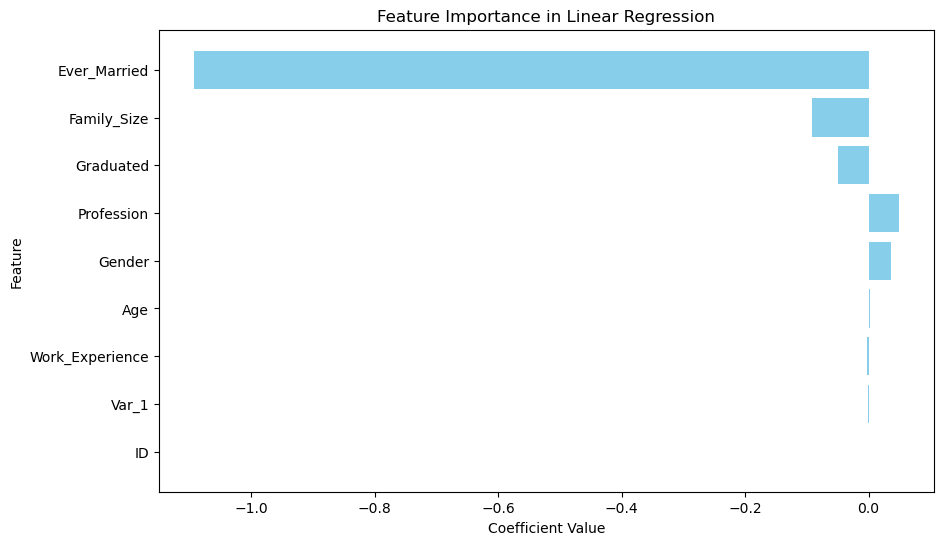

In [40]:
#For linear regression

feature_names = X_train.columns

coefficients = lr_model.coef_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance_df['Abs_Coefficient'] = np.abs(importance_df['Coefficient'])
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Linear Regression')
plt.gca().invert_yaxis()
plt.show()

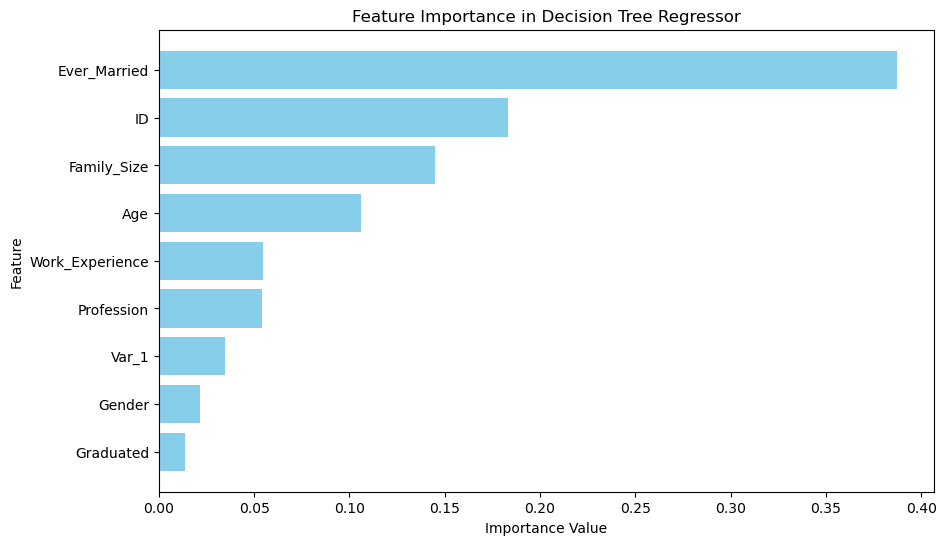

In [41]:
#For Decision Tree Regressor

feature_names = X_train.columns

importances = dt_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree Regressor')
plt.gca().invert_yaxis()
plt.show()

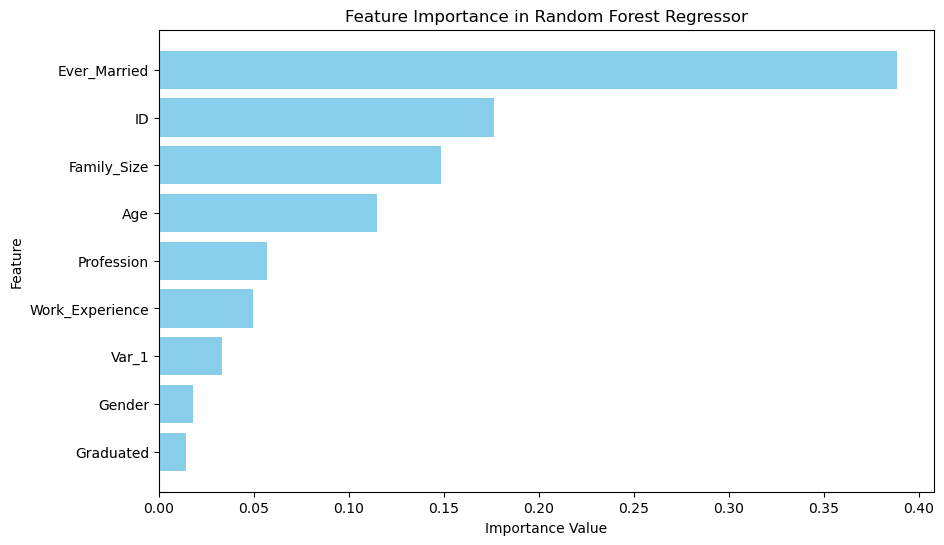

In [42]:
# For Random Forest Regressor
feature_names = X_train.columns

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Regressor')
plt.gca().invert_yaxis()
plt.show()

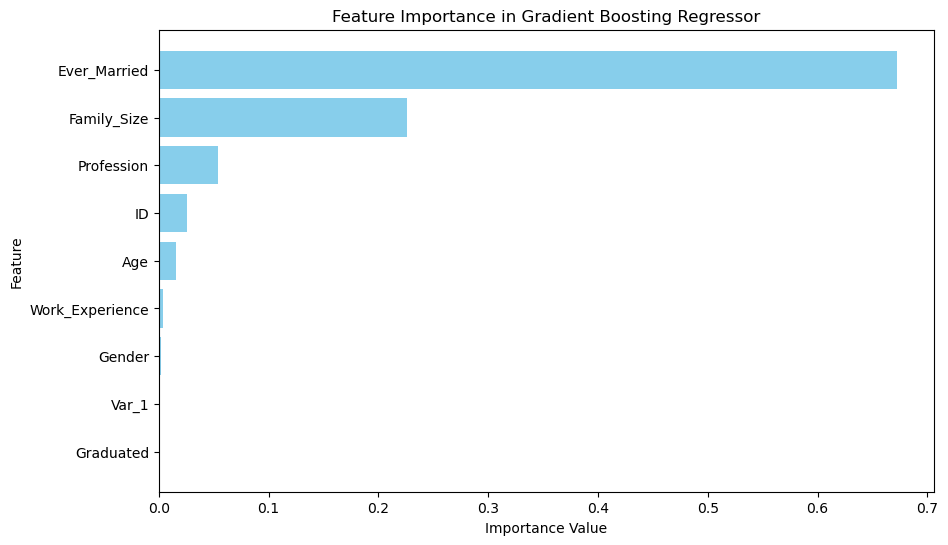

In [43]:
# For Gradient Boosting Regressor

feature_names = X_train.columns

importances = gbm_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Gradient Boosting Regressor')
plt.gca().invert_yaxis()
plt.show()